# 03 — Pit-time-loss model refinement: CV, circuit encoding, SC/VSC recovery

Phase 3's first pass technically beat baseline (5212 vs 5435 ms) but the
predicted-vs-actual scatter told the real story: predictions barely moved
off the circuit mean, and a handful of stops in the 70k-98k ms range sat
far from the trend line.

This revision fixes two bugs found during review, on top of the original
three-part refinement (SC/VSC recovery filtering, CV hyperparameter
search, circuit-encoding comparison):

1. **`laps_since_caution` had an uncapped counter.** For any stop that
   happened without a recent caution, the "laps since caution" feature was
   really just `20-ish + how-late-in-the-race-it-is` in disguise — a
   race-progress leak, not a real caution signal. Fixed in `features.py`
   by capping the counter (`LAPS_SINCE_CAUTION_CAP = 20`).
2. **Encoding comparison and feature ablation were deciding based on the
   validation set.** Both checks picked a winner by looking at `val` MAE
   directly — which means by the time the "final honest MAE" was
   reported, `val` had already been peeked at multiple times to make
   choices. Fixed by moving both onto the same rolling-origin CV used for
   hyperparameter search. `val` (rounds 16-22) is now touched exactly
   once, at the very end.

Both fixes now live in `train.py`, which is the single source of truth for
this pipeline. **This notebook imports its CV/search functions from
`train.py` rather than keeping its own copy** — the entire reason bug #2
above went unnoticed for a while is that logic like this drifting between
a notebook and the production script is easy to miss.

---

**Before running:** if you've had a Python kernel open in this repo before
today, restart it now. The very next cell will fail loudly (on purpose) if
you're running against a stale, pre-fix `features.py` module.

In [1]:
from pathlib import Path
import sys
import os

def find_backend_dir(start: Path) -> Path:
    """Walk upward until we find the backend directory."""
    candidates = [start] + list(start.parents)
    for p in candidates:
        maybe = p if p.name == "backend" else p / "backend"
        if (maybe / "ingestion").is_dir() and (maybe / ".env.example").exists():
            return maybe
    raise RuntimeError(
        f"Could not locate 'backend/' above {start}. "
        "Run this notebook from within the f1-strategy-lab repo."
    )

NOTEBOOK = Path.cwd()
BACKEND = find_backend_dir(NOTEBOOK)
PROJECT_ROOT = BACKEND.parent

# Allow imports like: from ml.pit_time.features import ...
sys.path.insert(0, str(BACKEND))
sys.path.insert(0, str(BACKEND / "ml" / "pit_time"))

from dotenv import load_dotenv

env_path = BACKEND / ".env"
load_dotenv(env_path)

import numpy as np
import pandas as pd
import sqlalchemy as sa
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

import ml.pit_time.features as features
import ml.pit_time.train as train

# --- Stale-kernel guard -----------------------------------------------
# This is the exact failure mode that cost a long debugging session last
# time: editing features.py on disk does nothing to a Python process that
# already imported the old version. This check fails immediately and
# loudly instead of silently producing numbers computed from the old,
# uncapped laps_since_caution counter.
EXPECTED_CAP = 20
if not hasattr(features, "LAPS_SINCE_CAUTION_CAP"):
    raise RuntimeError(
        "features.LAPS_SINCE_CAUTION_CAP is missing. This module was "
        "imported before the cap fix existed and Python is still using "
        "the cached version. RESTART THE KERNEL, then re-run this "
        "notebook from the top."
    )
if features.LAPS_SINCE_CAUTION_CAP != EXPECTED_CAP:
    raise RuntimeError(
        f"features.LAPS_SINCE_CAUTION_CAP is {features.LAPS_SINCE_CAUTION_CAP}, "
        f"expected {EXPECTED_CAP}. Check features.py on disk and restart the kernel."
    )

DATABASE_URL = os.getenv("DATABASE_URL")
if DATABASE_URL is None:
    raise RuntimeError(
        f"DATABASE_URL not found. Looked for it in {env_path}. "
        "Does that file exist and define DATABASE_URL=...?"
    )

engine = sa.create_engine(DATABASE_URL)

print(f"BACKEND resolved to: {BACKEND}")
print(f"features module loaded from: {features.__file__}")
print(f"LAPS_SINCE_CAUTION_CAP: {features.LAPS_SINCE_CAUTION_CAP}  (expected {EXPECTED_CAP} \u2713)")
print("Engine created OK.")

BACKEND resolved to: c:\Users\ASUS\Desktop\6-months projects\week 6 - end of phase 1\f1-strategy-lab\backend
features module loaded from: c:\Users\ASUS\Desktop\6-months projects\week 6 - end of phase 1\f1-strategy-lab\backend\ml\pit_time\features.py
LAPS_SINCE_CAUTION_CAP: 20  (expected 20 ✓)
Engine created OK.


## 1. Load data and build events (single source of truth: `features.build_pit_events`)

In [2]:
laps = pd.read_sql('''
    SELECT race_id, driver_id, lap_number, lap_time_ms, track_status
    FROM laps
''', engine)

pit_stops = pd.read_sql('''
    SELECT ps.race_id, ps.driver_id, ps.lap_number, ps.stop_duration_ms,
           r.round AS round, r.circuit AS circuit, d.team AS team
    FROM pit_stops ps
    JOIN races r ON r.id = ps.race_id
    JOIN drivers d ON d.id = ps.driver_id
''', engine)

events = features.build_pit_events(laps, pit_stops)
events = features.add_stint_number(events)

print(f"{len(events)} usable pit events out of {len(pit_stops)} raw "
      f"({len(pit_stops) - len(events)} dropped)")

342 usable pit events out of 538 raw (196 dropped)


In [3]:
caution_desc = events["laps_since_caution"].describe()
print(caution_desc)

# Sanity check on the fix itself, not just the constant: the max observed
# value must actually respect the cap. If this fails, something is
# recomputing laps_since_caution outside of features.py.
assert caution_desc["max"] <= features.LAPS_SINCE_CAUTION_CAP, (
    "laps_since_caution exceeds its cap in the actual data — the fix "
    "isn't taking effect. Restart the kernel and re-run from the top."
)
print(f"\n\u2713 max observed ({caution_desc['max']:.0f}) is within the cap "
      f"({features.LAPS_SINCE_CAUTION_CAP})")

count    342.000000
mean      16.125731
std        5.950330
min        2.000000
25%       12.250000
50%       20.000000
75%       20.000000
max       20.000000
Name: laps_since_caution, dtype: float64

✓ max observed (20) is within the cap (20)


## 2. Train/validation split (time-aware — same as Phase 2)

In [4]:
TRAIN_ROUNDS = train.TRAIN_ROUNDS
VAL_ROUNDS = train.VAL_ROUNDS

train_events = events[events["round"].isin(TRAIN_ROUNDS)].copy()
val_events = events[events["round"].isin(VAL_ROUNDS)].copy()
print(f"Train: {len(train_events)} | Validate: {len(val_events)}")

Train: 233 | Validate: 109


## 3. Baselines

- Per-circuit historical mean (the number every model must beat).
- The *shared* model: same RandomForest(200, 6, 5) and same feature set
  (minus `laps_since_caution`) as the Phase-3 first pass, re-run on the
  cleaner, SC/VSC-filtered event set. This isolates "did the filtering
  alone help" before touching hyperparameters or encoding.

In [5]:
baseline_means, baseline_global = features.circuit_mean_baseline(train_events)
baseline_pred = features.predict_baseline(val_events, baseline_means, baseline_global)
baseline_mae = mean_absolute_error(val_events["total_time_lost_ms"], baseline_pred)

te_map, global_mean = features.fit_circuit_target_encoding(train_events)
team_map = features.fit_team_encoding(train_events)

FIRST_PASS_FEATURES = [c for c in features.FEATURE_COLUMNS if c != "laps_since_caution"]

def make_matrix(ev, cols):
    m = features.build_feature_matrix(ev, te_map, global_mean, team_map)
    return m[cols]

X_train_shared = make_matrix(train_events, FIRST_PASS_FEATURES)
X_val_shared = make_matrix(val_events, FIRST_PASS_FEATURES)
y_train = train_events["total_time_lost_ms"]
y_val = val_events["total_time_lost_ms"]

shared_model = RandomForestRegressor(
    n_estimators=200, max_depth=6, min_samples_leaf=5, random_state=42
).fit(X_train_shared, y_train)
shared_pred = shared_model.predict(X_val_shared)
shared_mae = mean_absolute_error(y_val, shared_pred)

print(f"Per-circuit mean baseline MAE: {baseline_mae:.2f} ms")
print(f"Shared model baseline MAE (re-run on cleaner events): {shared_mae:.2f} ms")

Per-circuit mean baseline MAE: 5051.37 ms
Shared model baseline MAE (re-run on cleaner events): 4760.81 ms


## 4. Rolling-origin CV folds (within training rounds only)

Expanding-window folds — never plain k-fold, and never touching rounds
16-22. This is imported from `train.py`; **every model-selection decision
from here on (hyperparameters, encoding, whether to keep
`laps_since_caution`) uses these same folds, not the validation set.**

In [6]:
folds = train.expanding_round_folds(train_events["round"])
for i, (tr, va) in enumerate(folds):
    print(f"Fold {i}: train rounds {tr[0]}-{tr[-1]} ({len(tr)} rounds) | val rounds {va}")

Fold 0: train rounds 1-5 (5 rounds) | val rounds [np.int64(6), np.int64(7)]
Fold 1: train rounds 1-7 (7 rounds) | val rounds [np.int64(8), np.int64(9)]
Fold 2: train rounds 1-9 (9 rounds) | val rounds [np.int64(10), np.int64(11)]
Fold 3: train rounds 1-11 (11 rounds) | val rounds [np.int64(12), np.int64(13)]


## 5. Hyperparameter search (CV)

Same grid as before (`train.PARAM_GRID`), scored by CV MAE — the search
logic itself lives in `train.run_hyperparameter_search` so this notebook
can't silently drift from what `train.py` actually does at retrain time.

In [7]:
cv_df = train.run_hyperparameter_search(train_events, folds, features.FEATURE_COLUMNS)
print(cv_df.head(10))

   n_estimators  max_depth  min_samples_leaf     mean_mae      std_mae  \
0           200          8                 3  5723.350586  1988.676239   
1           200          6                 3  5728.450061  1974.182508   
2           100          8                 3  5746.859589  1942.449274   
3           100          6                 3  5755.339613  1940.125494   
4           200          4                 3  5778.874482  1834.978803   
5           100          4                 3  5801.512884  1800.968768   
6           200          4                 5  5812.353558  1718.297823   
7           200          6                 5  5835.142743  1757.359711   
8           200          8                 5  5839.602045  1763.901631   
9           200          4                10  5840.425027  1717.366897   

   n_folds  
0        4  
1        4  
2        4  
3        4  
4        4  
5        4  
6        4  
7        4  
8        4  
9        4  


**Read the spread before picking a winner.** With only ~200 training
events (and even fewer per fold), fold-to-fold `std_mae` will likely be
close to or larger than the gap between the top few candidates — same
situation as Phase 2's tire-model tuning. If that's the case here too,
treat this as picking a *region* of reasonable configs (shallow-ish trees,
moderate `min_samples_leaf`), not a single precise winner.

In [8]:
top5 = cv_df.head(5)
spread = top5["mean_mae"].max() - top5["mean_mae"].min()
typical_std = top5["std_mae"].mean()
print(f"Spread among top 5 mean_mae: {spread:.2f} ms")
print(f"Typical fold std_mae in top 5: {typical_std:.2f} ms")
if spread < typical_std:
    print("(spread smaller than typical fold noise \u2014 picking a region, not a precise winner)")

best_params = {k: int(v) for k, v in
               cv_df.iloc[0][["n_estimators", "max_depth", "min_samples_leaf"]].items()}
print("\nSelected hyperparameters:", best_params)

Spread among top 5 mean_mae: 55.52 ms
Typical fold std_mae in top 5: 1936.08 ms
(spread smaller than typical fold noise — picking a region, not a precise winner)

Selected hyperparameters: {'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 3}


## 6. Circuit-encoding comparison (CV — **fixed to no longer use `val`**)

Holding the tuned hyperparameters fixed, compare an arbitrary-ID control
(no target information — the deliberately weak baseline), plain target
encoding (fit on all of train, applied to all of train — mild
self-leakage), and out-of-fold target encoding.

Earlier drafts of this notebook picked a winner here by checking `val`
MAE directly — meaning the "final honest MAE" later on would have already
been shaped by a decision made using the same data it claimed to be
honestly evaluating against. This version uses the same rolling-origin CV
as the hyperparameter search instead, so `val` stays untouched until the
very last step.

In [9]:
encoding_df = train.run_encoding_comparison(train_events, folds, features.FEATURE_COLUMNS, best_params)
print(encoding_df)

                                  encoding  cv_mean_mae   cv_std_mae
0              out-of-fold target encoding  5347.707261  1845.193829
1  plain target encoding (current default)  5723.350586  1988.676239
2   arbitrary ID (control, no target info)  8856.270226  1803.721687


**What this table tells you either way.** If the arbitrary-ID control
scores close to the target-encoded versions, `circuit` alone (regardless
of encoding scheme) is doing almost all the work and `team`/`stint_number`
are close to noise. If OOF clearly beats plain target encoding *by more
than the CV noise*, the self-leakage in plain encoding was real and worth
switching to permanently. `train.py` defaults to `"plain"`
(`train.PRODUCTION_ENCODING`) — change that constant, not this notebook,
if a future run makes a genuine, noise-beating case for OOF.

## 7. Feature ablation — `laps_since_caution` (CV — **fixed to no longer use `val`**)

Same fix as step 6: this now uses CV instead of checking `val` directly.

In [10]:
ablation_df = train.run_feature_ablation(train_events, folds, best_params)
print(ablation_df)

                  feature_set  cv_mean_mae   cv_std_mae
0  without laps_since_caution  5844.767232  2019.483638
1     with laps_since_caution  5723.350586  1988.676239


## 8. Final combined config — the *one* honest touch of the validation set

Everything above (hyperparameters, encoding, feature set) was decided
using CV within the training rounds only. This is the first and only cell
that evaluates anything against `val_events` (rounds 16-22).

In [11]:
chosen_encoding = train.PRODUCTION_ENCODING  # "plain" by default; see step 6
print(f"Using encoding: {chosen_encoding}")

if chosen_encoding == "oof":
    train_te_override = features.fit_circuit_target_encoding_oof(train_events)
else:
    train_te_override = None

X_train_final = features.build_feature_matrix(
    train_events, te_map, global_mean, team_map, circuit_te_override=train_te_override
)[features.FEATURE_COLUMNS]
# Validation always uses the plain full-train encoding, regardless of
# chosen_encoding.
X_val_final = features.build_feature_matrix(
    val_events, te_map, global_mean, team_map
)[features.FEATURE_COLUMNS]

final_model = RandomForestRegressor(random_state=42, **best_params).fit(X_train_final, y_train)
final_pred = final_model.predict(X_val_final)
final_mae = mean_absolute_error(y_val, final_pred)

print(f"Per-circuit baseline MAE:            {baseline_mae:.2f} ms")
print(f"Shared (unrefined) model MAE:         {shared_mae:.2f} ms")
print(f"Combined refined model MAE:           {final_mae:.2f} ms")
print(f"Improvement vs shared baseline model: {shared_mae - final_mae:.2f} ms")
print("Beats per-circuit baseline" if final_mae < baseline_mae else "Still does NOT beat baseline")

Using encoding: plain
Per-circuit baseline MAE:            5051.37 ms
Shared (unrefined) model MAE:         4760.81 ms
Combined refined model MAE:           4895.29 ms
Improvement vs shared baseline model: -134.47 ms
Beats per-circuit baseline


## 9. Feature importance — does the flat scatter plot's story hold up?

circuit_te            0.560941
team_code             0.233430
stint_number          0.128992
laps_since_caution    0.076638
dtype: float64


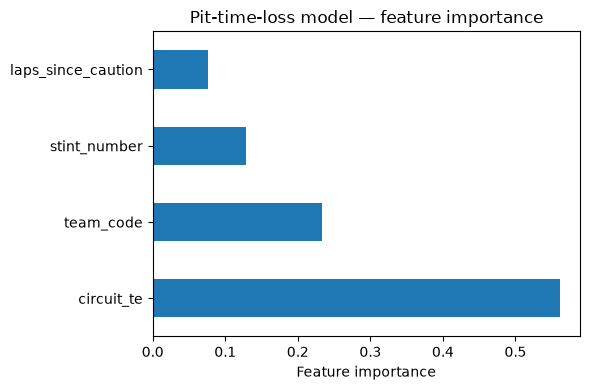

In [12]:
importances = pd.Series(
    final_model.feature_importances_, index=features.FEATURE_COLUMNS
).sort_values(ascending=False)
print(importances)

fig, ax = plt.subplots(figsize=(6, 4))
importances.plot(kind="barh", ax=ax)
ax.set_xlabel("Feature importance")
ax.set_title("Pit-time-loss model \u2014 feature importance")
plt.tight_layout()
plt.show()

If `circuit_te` still dominates and `team_code`/`stint_number` are near
zero, that's a legitimate, documentable limitation of the current
featurization — not something more tuning will fix. Compare
`laps_since_caution`'s importance here against the pre-fix run: it should
be meaningfully lower now that it can no longer act as a disguised
race-progress feature.

## 10. Predicted vs Actual — did the scatter actually move?

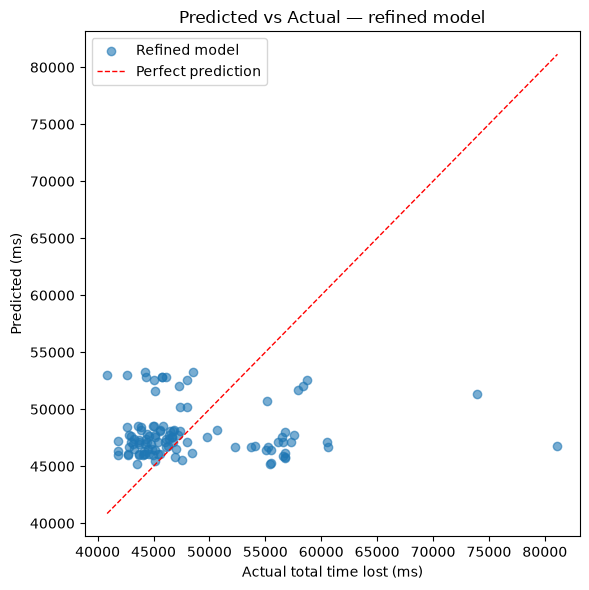

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_val, final_pred, alpha=0.6, label="Refined model")
lims = [min(y_val.min(), final_pred.min()), max(y_val.max(), final_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
ax.set_xlabel("Actual total time lost (ms)")
ax.set_ylabel("Predicted (ms)")
ax.set_title("Predicted vs Actual \u2014 refined model")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Per-circuit breakdown, refined model vs baseline

In [14]:
breakdown = val_events.copy()
breakdown["model_pred"] = final_pred
breakdown["baseline_pred"] = baseline_pred.values
breakdown["model_abs_err"] = (breakdown["total_time_lost_ms"] - breakdown["model_pred"]).abs()
breakdown["baseline_abs_err"] = (breakdown["total_time_lost_ms"] - breakdown["baseline_pred"]).abs()

per_circuit = (breakdown.groupby("circuit")[["model_abs_err", "baseline_abs_err"]]
               .mean().rename(columns={"model_abs_err": "model_mae", "baseline_abs_err": "baseline_mae"}))
per_circuit["model_wins"] = per_circuit["model_mae"] < per_circuit["baseline_mae"]
per_circuit.sort_values("model_mae")

,model_mae,baseline_mae,model_wins
circuit,,,
Mexico City,2635.882085,3827.252504,True
Austin,3174.013864,3301.798135,True
Suzuka,3702.918586,4725.367118,True
Yas Island,3789.875299,4190.393529,True
Las Vegas,6056.269029,6177.465359,True
Lusail,10038.204853,8877.186890,False


## 12. `laps_since_caution` vs target — confirming the gap is gone

Before the cap fix, this scatter had a hard gap between ~45 and ~100 —
the sentinel-driven artifact. It should be gone now, with a visible pile-up
of points at exactly 20 (everything "comfortably clear of any caution"
collapsed into one bucket).

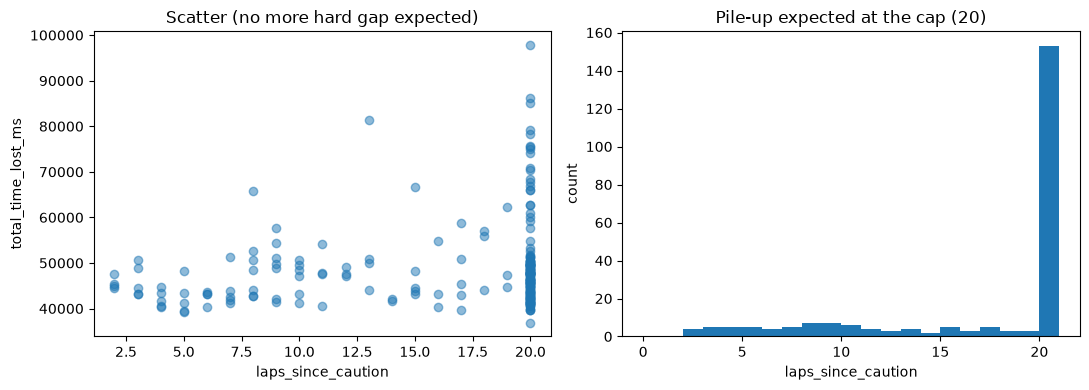

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(train_events["laps_since_caution"], train_events["total_time_lost_ms"], alpha=0.5)
axes[0].set_xlabel("laps_since_caution")
axes[0].set_ylabel("total_time_lost_ms")
axes[0].set_title("Scatter (no more hard gap expected)")

axes[1].hist(train_events["laps_since_caution"], bins=range(0, features.LAPS_SINCE_CAUTION_CAP + 2))
axes[1].set_xlabel("laps_since_caution")
axes[1].set_ylabel("count")
axes[1].set_title(f"Pile-up expected at the cap ({features.LAPS_SINCE_CAUTION_CAP})")

plt.tight_layout()
plt.show()